In [1]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

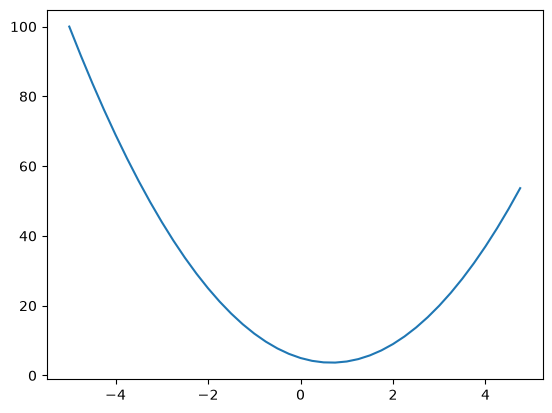

In [5]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [6]:
h = 0.000001
x = 2/3
(f(x + h) - f(x)) / h

2.999378523327323e-06

In [7]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
c += h
d2 = a*b + c
slope = (d2-d1) / h
print('d1',d1)
print('d2',d2)
print('slope',slope)


d1 4.0
d2 4.0001
slope 0.9999999999976694


In [63]:
class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data + other.data,(self,other),"+")

        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward
        return out
        

    def __mul__(self,other):
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1-t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b ; e.label='e'
d = e+c ; d.label='d'
f = Value(-2.0,label='f')
L = d*f ; L.label="L"
L

    


    

Value(data=-8.0)

In [10]:
d._op , d._prev

('+', {Value(data=-6.0), Value(data=10.0)})

In [11]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [11]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)

            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

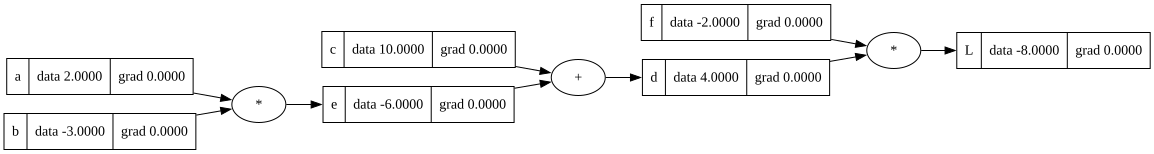

In [12]:
draw_dot(L)

In [13]:
L.grad = 1.0

d.grad = -2.0
f.grad = 4.0

e.grad = -2.0
c.grad = -2.0

a.grad = 6.0
b.grad = -4.0

In [14]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e+c
L = d*f

print(L.data)

-7.286496


In [15]:
print("a =", a.data, "grad =", a.grad)
print("b =", b.data, "grad =", b.grad)
print("c =", c.data, "grad =", c.grad)
print("f =", f.data, "grad =", f.grad)
print("L =", L.data)

a = 2.06 grad = 6.0
b = -3.04 grad = -4.0
c = 9.98 grad = -2.0
f = -1.96 grad = 4.0
L = -7.286496


In [16]:
def lol():

    h = 0.0001
    
    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a*b ; e.label='e'
    d = e+c ; d.label='d'
    f = Value(-2.0,label='f')
    L = d*f ; L.label="L"
    L1 = L.data


    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    b.data += h
    c = Value(10.0,label='c')
    e = a*b ; e.label='e'
    d = e+c ; d.label='d'
    f = Value(-2.0,label='f')
    L = d*f ; L.label="L"
    L2 = L.data + h

    print((L2-L1)/h)

lol()

    
    

-3.000000000010772


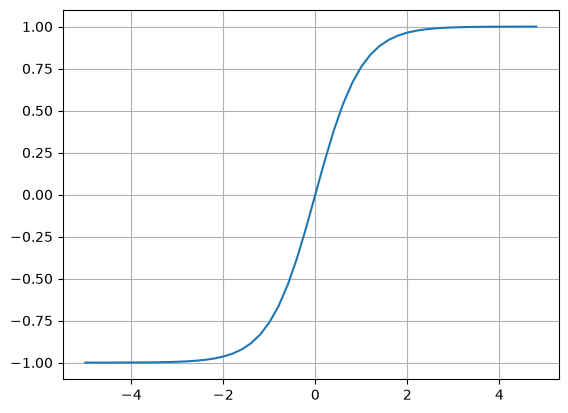

In [18]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2))); plt.grid()

In [64]:
#inputs
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
#bias
b = Value(6.881373587019543,label='b')
#x1w1 + x2w2 + b
x1w1 = x1*w1 ; x1w1.label = 'x1w1'
x2w2 = x2*w2 ; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1+x2*w2'
n = x1w1x2w2 + b ; n.label = 'n'
o = n.tanh()



In [51]:
o.grad = 1.0

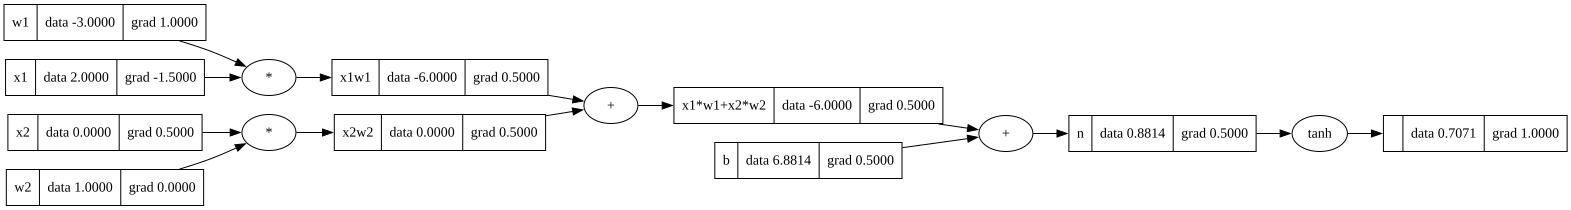

In [67]:
draw_dot(o)

In [66]:
o.backward()

In [53]:
o._backward()

In [55]:
n._backward()

In [57]:
b._backward()

In [59]:
x1w1x2w2._backward()

In [61]:
x1w1._backward()
x2w2._backward()

In [40]:
x2.grad = w2.data + x2w2.grad
w2.grad = x2.data + x2w2.grad

In [39]:
w1.grad = x1.data + x1w1.grad
x1.grad = w1.data + x1w1.grad


In [38]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [37]:
x1w1x2w2.grad = 0.5
b = 0.5

In [36]:
n.grad = 0.5

In [35]:
o.grad = 1.0

In [24]:
1 - o.data**2

0.4999999999999999